<a href="https://colab.research.google.com/github/Banj2/Banj2.github.io/blob/main/Tesla_Stock_Pred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Prep

In [72]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model, naive_bayes, ensemble ,tree, svm ,model_selection,preprocessing,\
 feature_extraction, metrics, base, pipeline
from joblib import dump,load
import PIL
from IPython.display import display
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import HuberRegressor

from sklearn.preprocessing import MinMaxScaler

In [73]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Files/TSLA_stock_data.csv')
display(df)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,1.266667,1.666667,1.169333,1.592667,1.592667,281494500
1,2010-06-30,1.719333,2.028000,1.553333,1.588667,1.588667,257806500
2,2010-07-01,1.666667,1.728000,1.351333,1.464000,1.464000,123282000
3,2010-07-02,1.533333,1.540000,1.247333,1.280000,1.280000,77097000
4,2010-07-06,1.333333,1.333333,1.055333,1.074000,1.074000,103003500
...,...,...,...,...,...,...,...
3587,2024-09-30,259.040009,264.859985,255.770004,261.630005,261.630005,80705700
3588,2024-10-01,262.670013,263.980011,248.529999,258.019989,258.019989,87397600
3589,2024-10-02,247.550003,251.160004,241.500000,249.020004,249.020004,93983900
3590,2024-10-03,244.479996,249.789993,237.809998,240.660004,240.660004,80729200


In [74]:
df.isna().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [75]:
print(f"number of duplicates: {np.sum(df.duplicated())}")

df.drop_duplicates(inplace=True)
print(f"number of duplicates after: {np.sum(df.duplicated())}")

number of duplicates: 0
number of duplicates after: 0


In [76]:
df.drop(['Adj Close'], axis = 1, inplace = True)

In [77]:
df['Date'] = pd.to_datetime(df['Date'])

df['year'] =  df['Date'].dt.year
df['month'] =  df['Date'].dt.month
df['day'] =  df['Date'].dt.day



In [78]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'year', 'month',
       'day'],
      dtype='object')

<Axes: >

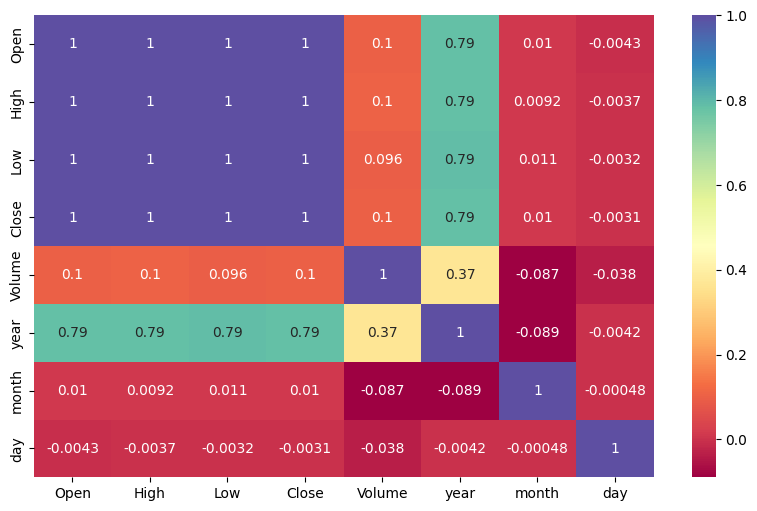

In [79]:
correlation_matrix = df[[ 'Open', 'High', 'Low', 'Close', 'Volume', 'year', 'month',
       'day']].corr()

plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, cmap='Spectral')

normally, the values with the closest location of 1 should be dropped in this row , but the dataset is about stocks, which naturally has correlation. no columns were dropped except the adj close, where it is the same as the target.

In [80]:
display(df)

,Date,Open,High,Low,Close,Volume,year,month,day
0,2010-06-29,1.266667,1.666667,1.169333,1.592667,281494500,2010,6,29
1,2010-06-30,1.719333,2.028000,1.553333,1.588667,257806500,2010,6,30
2,2010-07-01,1.666667,1.728000,1.351333,1.464000,123282000,2010,7,1
3,2010-07-02,1.533333,1.540000,1.247333,1.280000,77097000,2010,7,2
4,2010-07-06,1.333333,1.333333,1.055333,1.074000,103003500,2010,7,6
...,...,...,...,...,...,...,...,...,...
3587,2024-09-30,259.040009,264.859985,255.770004,261.630005,80705700,2024,9,30
3588,2024-10-01,262.670013,263.980011,248.529999,258.019989,87397600,2024,10,1
3589,2024-10-02,247.550003,251.160004,241.500000,249.020004,93983900,2024,10,2
3590,2024-10-03,244.479996,249.789993,237.809998,240.660004,80729200,2024,10,3


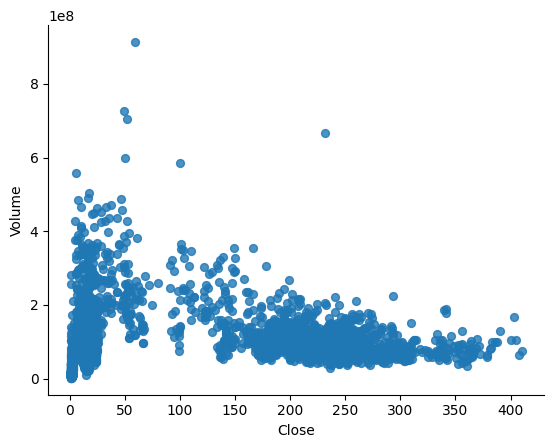

In [81]:
# @title Close vs Volume

from matplotlib import pyplot as plt
df.plot(kind='scatter', x='Close', y='Volume', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

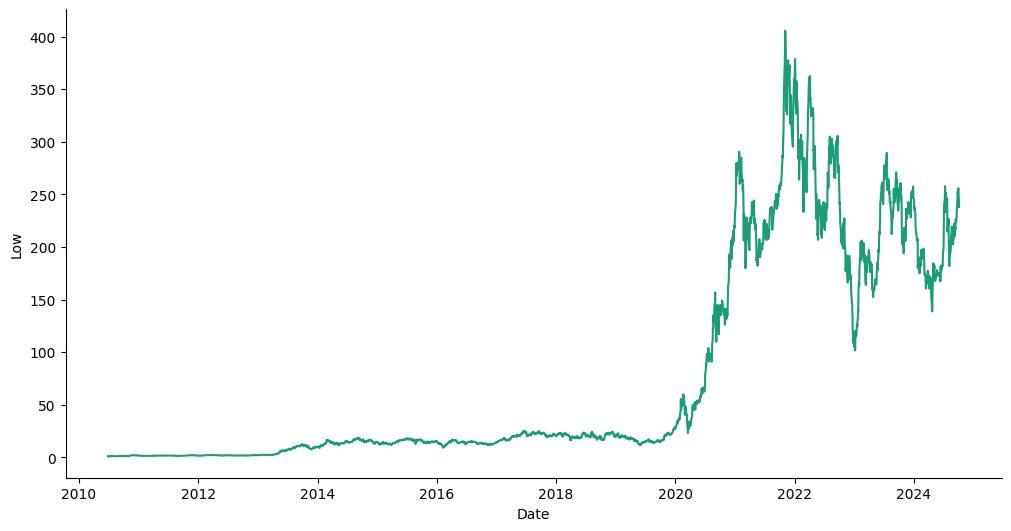

In [82]:
# @title Date vs Low

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Date']
  ys = series['Low']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = df.sort_values('Date', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Date')
_ = plt.ylabel('Low')


the base on the graph shown, there was no significant increases up until the year 2020, which means that  

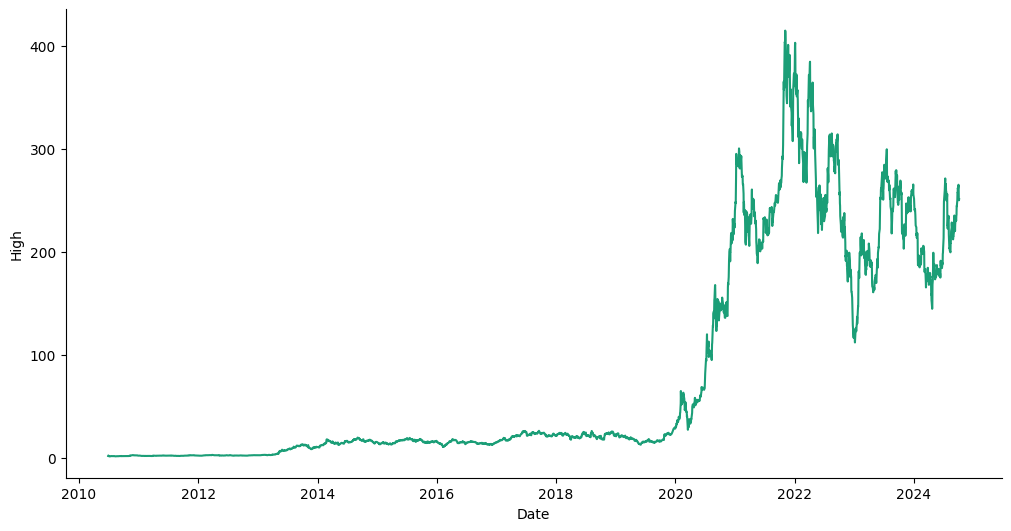

In [83]:
# @title Date vs High

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Date']
  ys = series['High']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = df.sort_values('Date', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Date')
_ = plt.ylabel('High')

In [84]:
import plotly.graph_objects as go
fig = go.Figure(data=[go.Candlestick(x=df['Date'],
                open=df['Open'],
                high=df['High'],
                low=df['Low'],
                close=df['Close'])])
fig.update_layout(
    title='Tesla Stock Market Data 2010-2024( this graph is interactive)',
    yaxis_title='Tesla Stock',
)

fig.show()

in the graph presented, Tesla's  stocks had a steady trend in stocks ranging around 0-20 in the year 2010 to 2019. this means that through out this  specific Time range, almost nobody was buying the stocks of tesla. however tesla has risen signficantly in stocks. this  means that tesla gained popularity during the pandemic. Their stocks are at their highest peak when 2022 was appoaching near. but their stocks a sharp decrease from 2022 to 2023. this could mean that somewhere along 2022, something must have happened . this could be some controversy within the company  or something else.

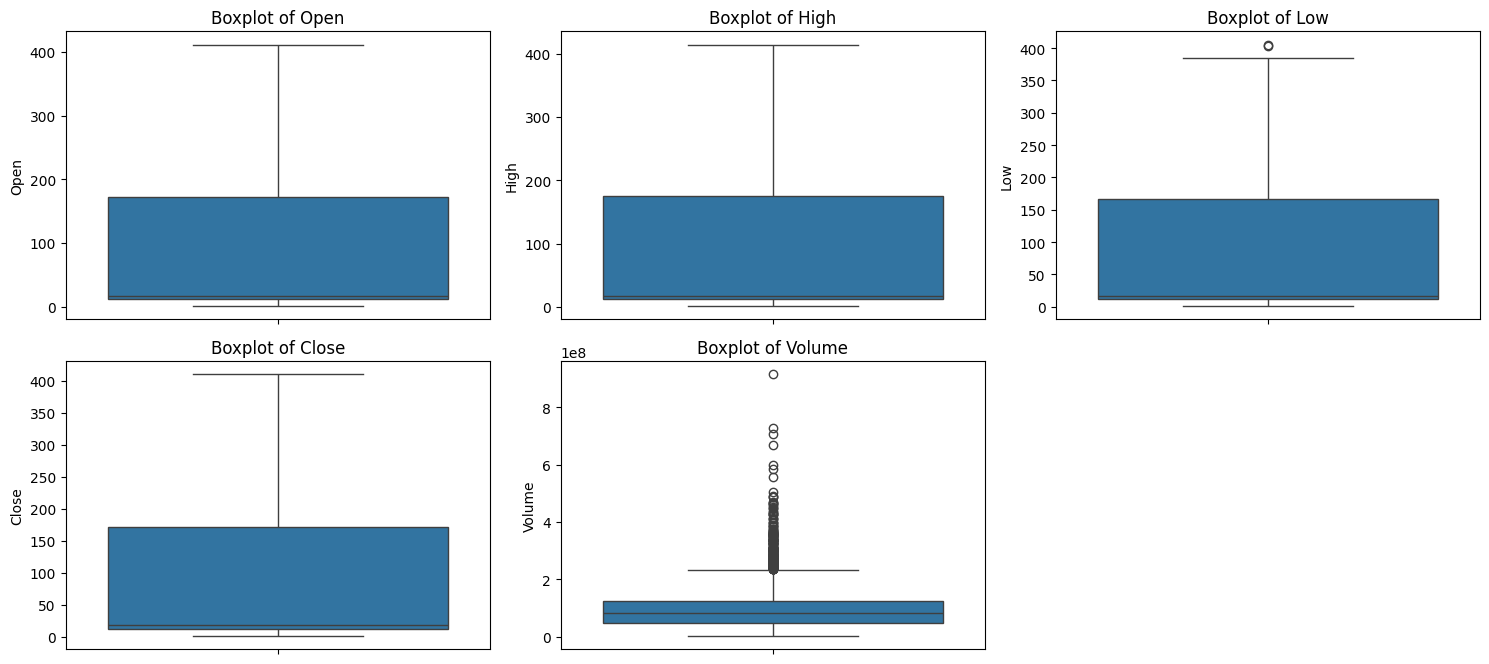

In [85]:
numeric_columns = ['Open', 'High', 'Low', 'Close','Volume']

plt.figure(figsize=(15,10))
for i, column in enumerate(numeric_columns, 1):
  plt.subplot(3,3,i)
  sns.boxplot(df[column])
  plt.title(f'Boxplot of {column}')
plt.tight_layout()
plt.show()


In [86]:
df['Volume'] = np.log(df['Volume'] + 1)
df['Low'] = np.log(df['Low'] + 1)

In [87]:
df.drop(['Date',], axis = 1, inplace = True)

In [88]:
scalar = StandardScaler()

x_train = scalar.fit_transform(df[['Open','High','Low','Volume']])

In [89]:
# if KNN or Linear Regression ang model
#FOR random forest, keep symbols, no need to scale
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[['year','month','day',]] = scaler.fit_transform(df[['year','month','day',]])

In [90]:
x = df.drop('Close', axis=1)
y = df['Close']

In [91]:
display(df)

,Open,High,Low,Close,Volume,year,month,day
0,1.266667,1.666667,0.774420,1.592667,19.455623,0.0,0.454545,0.933333
1,1.719333,2.028000,0.937400,1.588667,19.367720,0.0,0.454545,0.966667
2,1.666667,1.728000,0.854982,1.464000,18.629985,0.0,0.545455,0.000000
3,1.533333,1.540000,0.809744,1.280000,18.160575,0.0,0.545455,0.033333
4,1.333333,1.333333,0.720438,1.074000,18.450274,0.0,0.545455,0.166667
...,...,...,...,...,...,...,...,...
3587,259.040009,264.859985,5.548181,261.630005,18.206320,1.0,0.727273,0.966667
3588,262.670013,263.980011,5.519579,258.019989,18.285978,1.0,0.818182,0.000000
3589,247.550003,251.160004,5.491002,249.020004,18.358634,1.0,0.818182,0.033333
3590,244.479996,249.789993,5.475668,240.660004,18.206611,1.0,0.818182,0.066667


#Model with Correlated columns

In [45]:
x_train, x_test, y_train, y_test = model_selection.train_test_split(x,y, test_size= 0.2, random_state=22,)

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
mse = metrics.mean_squared_error(y_test, y_pred)#mean Squared Error
r2 = metrics.r2_score(y_test, y_pred) #R Squared Value

In [ ]:
import math
#print results
print("Mean Squared Error:",mse)
print("RMSE:",math.sqrt(mse))
print("R-squared:",r2)

#optional: View The coefficients(weights of the Model)
print('Coefficients:',model.coef_)
print('Intercept:',model.intercept_)

Mean Squared Error: 9.161673075200264
RMSE: 3.0268255772674224
R-squared: 0.9991610772705878
Coefficients: [-0.3122271   1.27420587  0.84968363 -0.76208596  0.01446752  0.28704326
  0.00397927]
Intercept: 11.654009321463164


# New Model (GBM) with Correlated Columns

In [68]:
x_train, x_test, y_train, y_test = model_selection.train_test_split(x,y, test_size= 0.2, random_state=22,)

In [69]:
from sklearn.ensemble import GradientBoostingRegressor
gbm = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# Train the model
gbm.fit(x_train, y_train)

# Make predictions
y_pred = gbm.predict(x_test)


In [70]:
mse = metrics.mean_squared_error(y_test, y_pred)#mean Squared Error
r2 = metrics.r2_score(y_test, y_pred) #R Squared Value

In [71]:
import math
#print results
print("Mean Squared Error:",mse)
print("RMSE:",math.sqrt(mse))
print("R-squared:",r2)



Mean Squared Error: 6.810488110607515
RMSE: 2.6096911906598286
R-squared: 0.9993763722818438


# Model with removed columns


In [ ]:
df.drop(['Open','High', 'Low'], axis = 1, inplace = True)

In [ ]:
x_train, x_test, y_train, y_test = model_selection.train_test_split(x,y, test_size= 0.2, random_state=22,)

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
mse = metrics.mean_squared_error(y_test, y_pred)#mean Squared Error
r2 = metrics.r2_score(y_test, y_pred) #R Squared Value

In [ ]:
import math
#print results
print("Mean Squared Error:",mse)
print("RMSE:",math.sqrt(mse))
print("R-squared:",r2)

#optional: View The coefficients(weights of the Model)
print('Coefficients:',model.coef_)
print('Intercept:',model.intercept_)

Mean Squared Error: 9.161673075200264
RMSE: 3.0268255772674224
R-squared: 0.9991610772705878
Coefficients: [-0.3122271   1.27420587  0.84968363 -0.76208596  0.01446752  0.28704326
  0.00397927]
Intercept: 11.654009321463164


# New Model (GBM) without Correlated Columns

In [92]:
df.drop(['Open','High', 'Low'], axis = 1, inplace = True)

In [93]:
x_train, x_test, y_train, y_test = model_selection.train_test_split(x,y, test_size= 0.2, random_state=22,)

In [94]:
from sklearn.ensemble import GradientBoostingRegressor
gbm = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# Train the model
gbm.fit(x_train, y_train)

# Make predictions
y_pred = gbm.predict(x_test)



In [95]:
mse = metrics.mean_squared_error(y_test, y_pred)#mean Squared Error
r2 = metrics.r2_score(y_test, y_pred) #R Squared Value

In [96]:
import math
#print results
print("Mean Squared Error:",mse)
print("RMSE:",math.sqrt(mse))
print("R-squared:",r2)



Mean Squared Error: 6.810488110607515
RMSE: 2.6096911906598286
R-squared: 0.9993763722818438
